In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.cluster.hierarchy import dendrogram
from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering
import plotly.express as px
from sklearn.decomposition import PCA

In [2]:
def plot_dendrogram(model, **kwargs):

    # Children of hierarchical clustering
    children = model.children_

    # Distances between each pair of children
    # Since we don't have this information, we can use a uniform one for plotting
    distance = np.arange(children.shape[0])

    # The number of observations contained in each cluster level
    no_of_observations = np.arange(2, children.shape[0]+2)

    # Create linkage matrix and then plot the dendrogram
    linkage_matrix = np.column_stack([children, distance, no_of_observations]).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)

In [ ]:
iris = load_iris()
x = pd.DataFrame(iris.data, columns=iris.feature_names)
x['target'] = iris.target
x = x.reset_index()
x

In [5]:
sx=x.sample(10).reset_index(drop=True)
sx

,index,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,62,6.0,2.2,4.0,1.0,1
1,63,6.1,2.9,4.7,1.4,1
2,40,5.0,3.5,1.3,0.3,0
3,139,6.9,3.1,5.4,2.1,2
4,98,5.1,2.5,3.0,1.1,1
5,17,5.1,3.5,1.4,0.3,0
6,76,6.8,2.8,4.8,1.4,1
7,97,6.2,2.9,4.3,1.3,1
8,114,5.8,2.8,5.1,2.4,2
9,50,7.0,3.2,4.7,1.4,1


In [ ]:
pca = PCA(n_components=2)
pca_df = pd.DataFrame( 
    pca.fit_transform(
        sx[[
            'sepal length (cm)', 
            'sepal width (cm)', 
            'petal length (cm)',
            'petal width (cm)'
        ]]
    ), 
    columns=['pc1','pc2'] 
).round(2)
pca_df['target'] = sx['target']
pca_df['target'] = pca_df['target'].astype('string')
pca_df = pca_df.reset_index()

In [7]:
pca_df

,index,pc1,pc2,target
0,0,0.09,-0.29,1
1,1,0.80,-0.10,1
2,2,-2.96,0.21,0
3,3,1.92,0.27,2
4,4,-1.10,-0.74,1
5,5,-2.84,0.27,0
6,6,1.15,0.37,1
7,7,0.46,0.07,1
8,8,1.38,-0.80,2
9,9,1.10,0.74,1


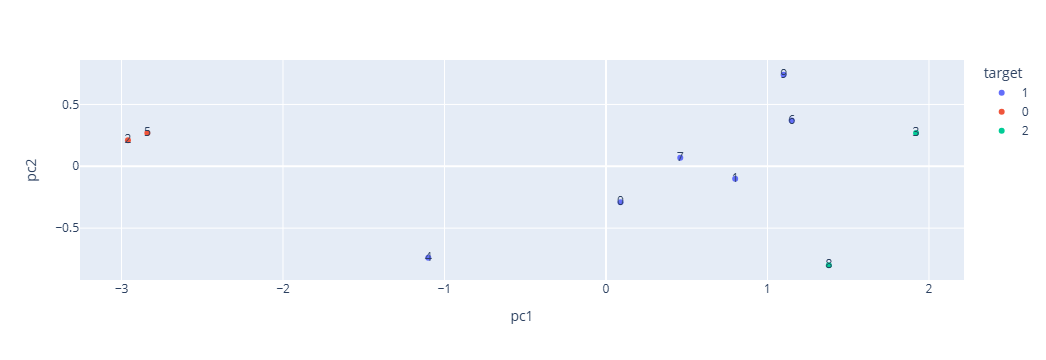

In [8]:
px.scatter(pca_df, x='pc1',y='pc2',color='target',text='index')

In [9]:
model = AgglomerativeClustering(n_clusters=3)
model = model.fit(sx)
sx['dendo_labels'] = model.labels_

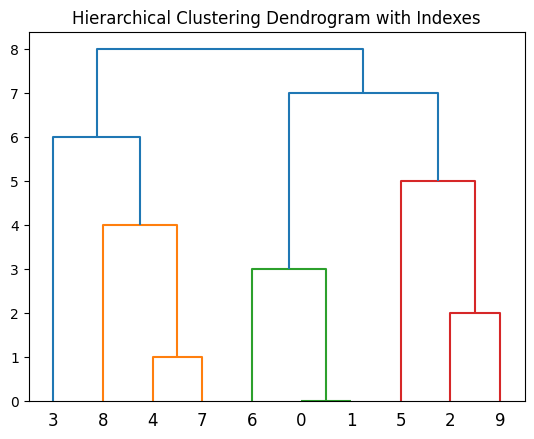

In [10]:
plt.title('Hierarchical Clustering Dendrogram with Indexes')
plot_dendrogram(model, labels=sx.index)
plt.show()

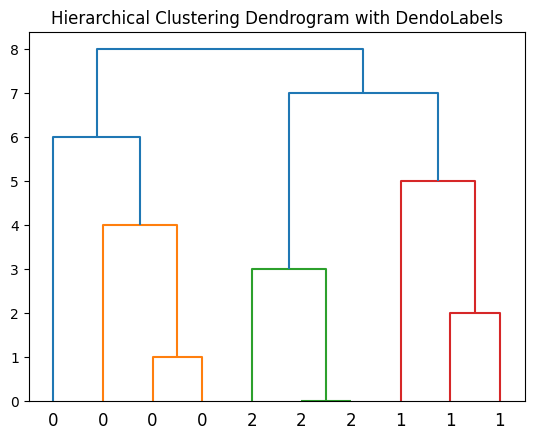

In [11]:
plt.title('Hierarchical Clustering Dendrogram with DendoLabels')
plot_dendrogram(model, labels=model.labels_)
plt.show()

In [12]:
sx

,index,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,dendo_labels
0,9,4.9,3.1,1.5,0.1,0,2
1,99,5.7,2.8,4.1,1.3,1,1
2,64,5.6,2.9,3.6,1.3,1,0
3,25,5.0,3.0,1.6,0.2,0,2
4,42,4.4,3.2,1.3,0.2,0,0
5,125,7.2,3.2,6.0,1.8,2,1
6,46,5.1,3.8,1.6,0.2,0,0
7,36,5.5,3.5,1.3,0.2,0,0
8,113,5.7,2.5,5.0,2.0,2,1
9,12,4.8,3.0,1.4,0.1,0,2
